# Hands-On Week 8 — Probability Concepts for Data Science (Python)

**Mata kuliah:** Pengantar Data Sains  
**Fokus minggu ini:** konsep peluang, variabel acak, distribusi peluang, nilai harapan, varians, simulasi, LLN, CLT, dan Simulasi Monte Carlo  

Notebook ini disusun agar mahasiswa tidak hanya menjalankan kode, tetapi juga memahami **makna statistik** di balik setiap output.

## Tujuan pembelajaran

Setelah menyelesaikan notebook ini, mahasiswa diharapkan mampu:

1. menjelaskan konsep eksperimen acak, ruang sampel, dan kejadian,
2. membedakan variabel acak diskrit dan kontinu,
3. memahami PMF, PDF, dan CDF secara konseptual,
4. mengenali distribusi peluang yang umum dalam data science,
5. menghitung dan menafsirkan **nilai harapan** serta **varians**,
6. menggunakan Python untuk simulasi distribusi peluang,
7. menjelaskan secara intuitif **Law of Large Numbers (LLN)**, **Central Limit Theorem (CLT)**, **Simulasi Monte Carlo**.

## Alur praktikum

Praktikum ini dibagi menjadi delapan bagian:

1. pengantar probabilitas dalam data science,  
2. eksperimen acak, ruang sampel, dan kejadian,  
3. variabel acak dan distribusi peluang,  
4. distribusi diskrit,  
5. distribusi kontinu,  
6. nilai harapan dan varians,  
7. simulasi, LLN, CLT, dan Monte Carlo,  
8. latihan, refleksi, dan tugas mandiri.

## 1. Import library

Kita akan menggunakan:

- **NumPy** untuk komputasi numerik dan simulasi acak,
- **Pandas** untuk tabel ringkas,
- **Matplotlib** untuk visualisasi,
- **SciPy** untuk fungsi distribusi peluang yang sudah siap pakai.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, poisson, geom
from scipy.stats import uniform, norm, expon, gamma, beta, chi2, t

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", None)

# agar hasil simulasi reprodusibel
np.random.seed(123)

print("Library berhasil diimpor.")

Library berhasil diimpor.


## 2. Mengapa probabilitas penting dalam data science?

Dalam data science, kita hampir selalu berhadapan dengan **ketidakpastian**. Misalnya:

- apakah pelanggan akan membeli produk,
- berapa banyak pelanggan datang dalam satu jam,
- apakah email termasuk spam,
- apakah model akan benar pada data baru.

Probabilitas membantu kita untuk:

- memodelkan kejadian acak,
- memahami ketidakpastian,
- membangun model prediktif,
- melakukan inferensi statistik,
- menjalankan simulasi untuk pengambilan keputusan.

## 3. Eksperimen acak, ruang sampel, dan kejadian

- **Eksperimen acak**: proses yang hasilnya belum pasti sebelum dilakukan.
- **Ruang sampel** ($S$): himpunan semua hasil yang mungkin.
- **Kejadian** ($A$): subset dari ruang sampel.

### Contoh
Jika satu dadu fair dilempar sekali, maka:

- ruang sampel: $S = \{1,2,3,4,5,6\}$
- kejadian “muncul bilangan genap”: $A = \{2,4,6\}$


In [ ]:
# contoh probabilitas klasik pada lemparan satu dadu
sample_space = np.array([1, 2, 3, 4, 5, 6])
event_even = sample_space[sample_space % 2 == 0]

prob_even = len(event_even) / len(sample_space)

print("Ruang sampel:", sample_space)
print("Kejadian genap:", event_even)
print("P(genap) =", prob_even)

Ruang sampel: [1 2 3 4 5 6]
Kejadian genap: [2 4 6]
P(genap) = 0.5


### Interpretasi

Peluang muncul mata dadu genap adalah **3 dari 6 hasil yang mungkin**, sehingga:

Peluangnya adalah 0.5

Artinya, dalam jangka panjang, sekitar **50%** hasil lemparan dadu akan berupa bilangan genap.

## Checkpoint 1

**Pertanyaan:**  
Jika dua koin fair dilempar sekaligus, berapa peluang muncul **tepat satu gambar**?

Tuliskan ruang sampel terlebih dahulu, lalu hitung peluangnya.

In [ ]:
# ruang jawaban mahasiswa
# tulis jawaban Anda di bawah ini

## 4. Variabel acak

Variabel acak memetakan hasil eksperimen acak menjadi nilai numerik.

### Dua jenis utama
1. **Variabel acak diskrit**: nilainya dapat dihitung satu per satu.
   - contoh: jumlah sukses, jumlah pelanggan, jumlah cacat produk.
2. **Variabel acak kontinu**: nilainya berada pada suatu interval kontinu.
   - contoh: tinggi badan, waktu tunggu, suhu.

### Contoh sederhana
- $X$ = jumlah sisi gambar dari 3 lemparan koin → **diskrit**
- $Y$ = waktu tunggu pelanggan di loket → **kontinu**

## 5. PMF, PDF, dan CDF

### a. PMF (Probability Mass Function)
Untuk variabel acak **diskrit**, peluang pada titik tertentu dapat ditulis sebagai
\[
P(X=x)
\]

### b. PDF (Probability Density Function)
Untuk variabel acak **kontinu**, kita menggunakan fungsi densitas yang dinotasikan sebagai
\[
f(x)
\].

### c. CDF (Cumulative Distribution Function)
Baik untuk diskrit maupun kontinu CDF dinotasikan sebagai
\[
F(x)
\].
CDF menunjukkan peluang kumulatif sampai titik $x$.

### Catatan tambahan untuk CDF, probability, dan inverse quantile

Pada setiap distribusi di bawah ini, notebook sekarang menampilkan tiga hal:
1. **grafik PMF/PDF** untuk melihat bentuk distribusi,
2. **grafik CDF** untuk melihat peluang kumulatif,
3. **tabel quantile** untuk menghitung invers CDFpada beberapa kuantil seperti 10%, 25%, 50%, 75%, dan 90%.


## Struktur minimum untuk setiap distribusi

Praktikum ini memberikan beberapa komponen yang sering digunakan untuk membandingkan satu distribusi dengan distribusi lain, yaitu:

1. **Pembangkitan data atau random data**
2. **Pembuatan plot distribusi atau grafik densitas**
3. **Pembuatan plot distribusi kumulatif (CDF)**
4. **Perhitungan nilai peluang**
5. **Perhitungan nilai kuantil**

Untuk distribusi **diskrit**, plot distribusi menggunakan **PMF**.  
Untuk distribusi **kontinu**, plot distribusi menggunakan **PDF / densitas**.


# Bagian A — Distribusi Diskrit

Distribusi diskrit cocok untuk variabel acak yang nilainya **terhitung**.  
Pada notebook ini kita fokus pada empat distribusi yang sangat sering muncul dalam data science dasar:

1. Bernoulli  
2. Binomial  
3. Poisson  
4. Geometrik

## A1. Distribusi Bernoulli

Distribusi Bernoulli digunakan untuk **satu percobaan** dengan dua kemungkinan hasil:

- sukses = 1
- gagal = 0

### Contoh:
- email spam atau bukan spam,
- pelanggan membeli atau tidak,
- sensor aktif atau tidak aktif.

,Sampel Bernoulli
0,1
1,1
2,1
3,1
4,1
5,0
6,0
7,1
8,0
9,0


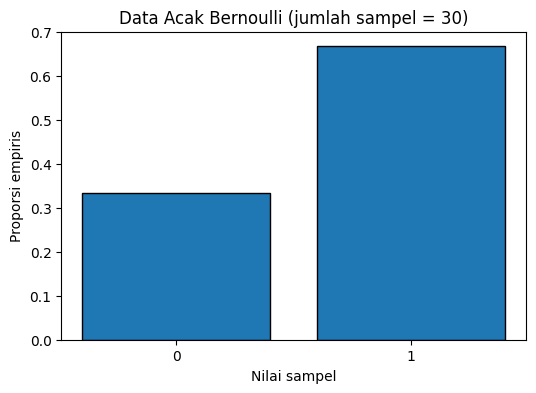

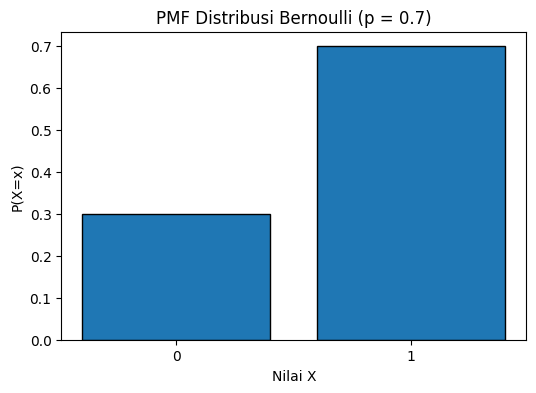

,x,P(X=x)
0,0,0.3
1,1,0.7


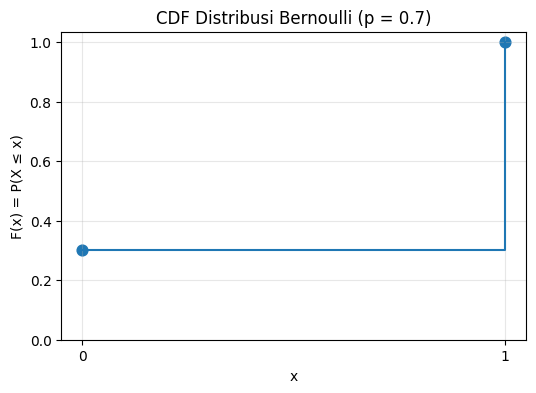

,Keterangan,Nilai
0,P(X=1),0.7
1,P(X=0),0.3
2,P(X≤0),0.3
3,P(X≤1),1.0


,quantile,inverse CDF,CDF
0,0.10,0,0.3
1,0.25,0,0.3
2,0.50,1,1.0
3,0.75,1,1.0
4,0.90,1,1.0


In [ ]:
# =========================================================
# Distribusi Bernoulli
# =========================================================
p = 0.7

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = bernoulli.rvs(p, size=30, random_state=rng)
display(pd.DataFrame({"Sampel Bernoulli": sample}).head(10))

plt.figure(figsize=(6, 4))
vals, counts = np.unique(sample, return_counts=True)
plt.bar(vals, counts / len(sample), edgecolor="black")
plt.xticks([0, 1])
plt.xlabel("Nilai sampel")
plt.ylabel("Proporsi empiris")
plt.title("Data Acak Bernoulli (jumlah sampel = 30)")
plt.show()

x = np.array([0, 1])

# 2) Plot distribusi (PMF)
pmf = bernoulli.pmf(x, p)
plt.figure(figsize=(6, 4))
plt.bar(x, pmf, edgecolor="black")
plt.xticks([0, 1])
plt.xlabel("Nilai X")
plt.ylabel("P(X=x)")
plt.title("PMF Distribusi Bernoulli (p = 0.7)")
plt.show()

display(pd.DataFrame({"x": x, "P(X=x)": pmf}))

# 3) Plot distribusi kumulatif (CDF)
cdf = bernoulli.cdf(x, p)
plt.figure(figsize=(6, 4))
plt.step(x, cdf, where="post")
plt.scatter(x, cdf, s=60)
plt.xticks([0, 1])
plt.yticks(np.linspace(0, 1, 6))
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF Distribusi Bernoulli (p = 0.7)")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X=1)",
        "P(X=0)",
        "P(X≤0)",
        "P(X≤1)"
    ],
    "Nilai": [
        bernoulli.pmf(1, p),
        bernoulli.pmf(0, p),
        bernoulli.cdf(0, p),
        bernoulli.cdf(1, p)
    ]
})
display(prob_table)

# 5) Perhitungan nilai kuantil dan inversnya
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
x_quant = bernoulli.ppf(quantiles, p).astype(int)
cdf_at_quant = bernoulli.cdf(x_quant, p)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))



### Interpretasi Bernoulli

Dengan $p=0.7$:

- peluang gagal = 0.3
- peluang sukses = 0.7

Ini berarti satu observasi tunggal lebih cenderung menghasilkan **sukses** daripada **gagal**.

## A2. Distribusi Binomial

Distribusi Binomial memodelkan **jumlah sukses** dari $n$ percobaan Bernoulli independen dengan peluang sukses tetap $p$.


### Contoh:
- jumlah pelanggan yang mengklik iklan dari 20 orang,
- jumlah soal benar dari 10 soal pilihan ganda,
- jumlah produk lolos quality control dari sejumlah item.

,Sampel Binomial
0,6
1,2
2,4
3,4
4,4
5,6
6,7
7,4
8,6
9,7


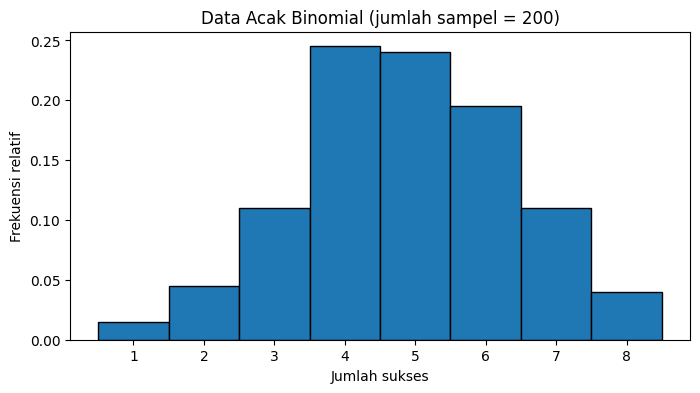

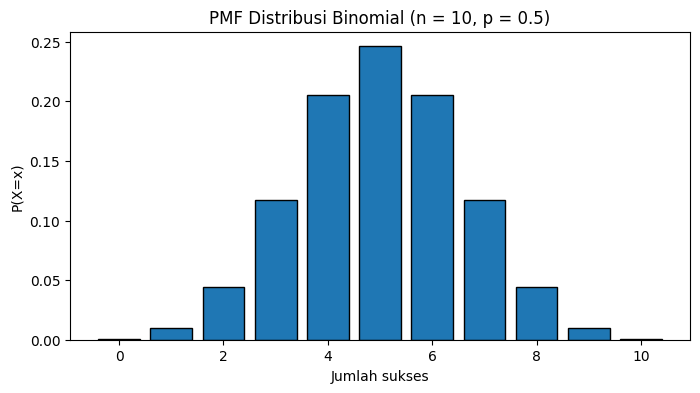

,x,P(X=x)
0,0,0.0010
1,1,0.0098
2,2,0.0439
3,3,0.1172
4,4,0.2051
5,5,0.2461
6,6,0.2051
7,7,0.1172
8,8,0.0439
9,9,0.0098


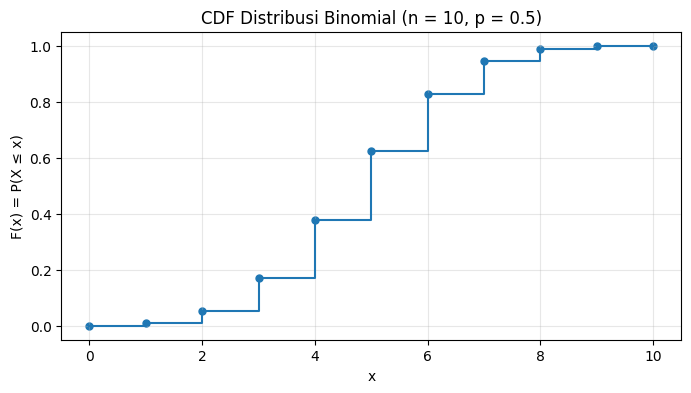

,Keterangan,Nilai
0,P(X=3),0.1172
1,P(X=5),0.2461
2,P(X≤3),0.1719
3,P(4≤X≤7),0.7734


,quantile,inverse CDF,CDF
0,0.10,3,0.1719
1,0.25,4,0.3770
2,0.50,5,0.6230
3,0.75,6,0.8281
4,0.90,7,0.9453


In [ ]:
# =========================================================
# Distribusi Binomial
# =========================================================
n, p = 10, 0.5

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = binom.rvs(n, p, size=200, random_state=rng)
display(pd.DataFrame({"Sampel Binomial": sample}).head(10))

plt.figure(figsize=(8, 4))
vals = np.arange(sample.min(), sample.max() + 1)
plt.hist(sample, bins=np.arange(sample.min() - 0.5, sample.max() + 1.5, 1),
         edgecolor="black", density=True)
plt.xlabel("Jumlah sukses")
plt.ylabel("Frekuensi relatif")
plt.title("Data Acak Binomial (jumlah sampel = 200)")
plt.show()

x = np.arange(0, n + 1)

# 2) Plot distribusi (PMF)
pmf = binom.pmf(x, n, p)
plt.figure(figsize=(8, 4))
plt.bar(x, pmf, edgecolor="black")
plt.xlabel("Jumlah sukses")
plt.ylabel("P(X=x)")
plt.title("PMF Distribusi Binomial (n = 10, p = 0.5)")
plt.show()

display(pd.DataFrame({"x": x, "P(X=x)": pmf}))

# 3) Plot CDF
cdf = binom.cdf(x, n, p)
plt.figure(figsize=(8, 4))
plt.step(x, cdf, where="post")
plt.scatter(x, cdf, s=25)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF Distribusi Binomial (n = 10, p = 0.5)")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X=3)",
        "P(X=5)",
        "P(X≤3)",
        "P(4≤X≤7)"
    ],
    "Nilai": [
        binom.pmf(3, n, p),
        binom.pmf(5, n, p),
        binom.cdf(3, n, p),
        binom.cdf(7, n, p) - binom.cdf(3, n, p)
    ]
})
display(prob_table)

# 5) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
x_quant = binom.ppf(quantiles, n, p).astype(int)
cdf_at_quant = binom.cdf(x_quant, n, p)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))



### Interpretasi Binomial

Distribusi binomial di atas simetris karena $p=0.5$.  
Nilai yang paling mungkin muncul berada di sekitar **5 sukses**, karena:
\[
E(X)=np=10(0.5)=5
\]

Semakin jauh dari 5, probabilitasnya makin kecil.

## A3. Distribusi Poisson

Distribusi Poisson digunakan untuk memodelkan **jumlah kejadian** dalam suatu interval waktu atau ruang ketika:

- kejadian saling independen,
- laju rata-rata kejadian konstan,
- kejadian dihitung sebagai jumlah.

### Contoh konteks
- jumlah pelanggan datang per jam,
- jumlah panggilan masuk per menit,
- jumlah error sistem per hari.

,Sampel Poisson
0,2
1,4
2,5
3,6
4,3
5,0
6,9
7,4
8,4
9,0


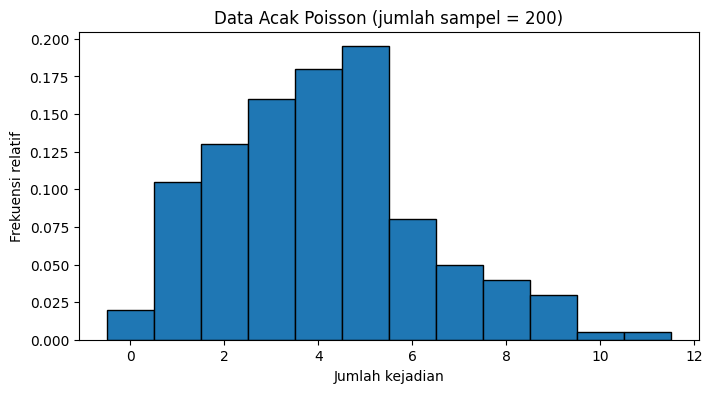

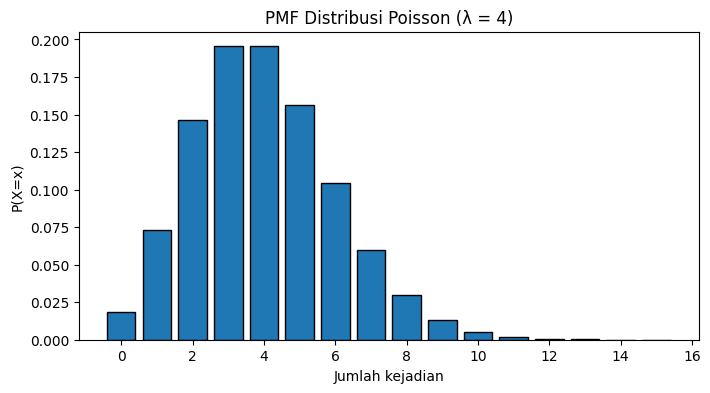

,x,P(X=x)
0,0,0.0183
1,1,0.0733
2,2,0.1465
3,3,0.1954
4,4,0.1954
5,5,0.1563
6,6,0.1042
7,7,0.0595
8,8,0.0298
9,9,0.0132


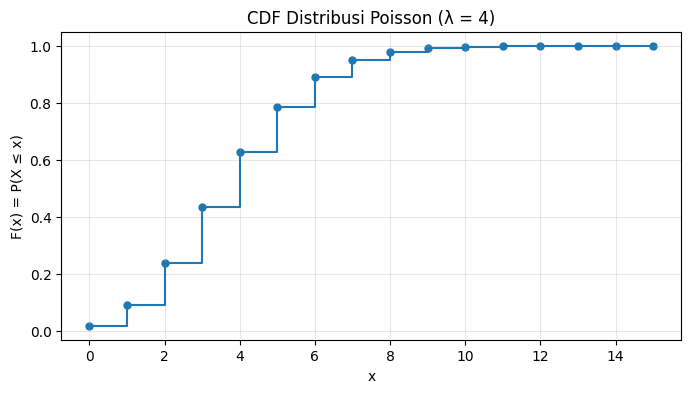

,Keterangan,Nilai
0,P(X=2),0.1465
1,P(X=4),0.1954
2,P(X≤3),0.4335
3,P(2≤X≤6),0.7977


,quantile,inverse CDF,CDF
0,0.10,2,0.2381
1,0.25,3,0.4335
2,0.50,4,0.6288
3,0.75,5,0.7851
4,0.90,7,0.9489


In [ ]:
# =========================================================
# Distribusi Poisson
# =========================================================
lam = 4

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = poisson.rvs(lam, size=200, random_state=rng)
display(pd.DataFrame({"Sampel Poisson": sample}).head(10))

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=np.arange(sample.min() - 0.5, sample.max() + 1.5, 1),
         edgecolor="black", density=True)
plt.xlabel("Jumlah kejadian")
plt.ylabel("Frekuensi relatif")
plt.title("Data Acak Poisson (jumlah sampel = 200)")
plt.show()

x = np.arange(0, 16)

# 2) Plot distribusi (PMF)
pmf = poisson.pmf(x, lam)
plt.figure(figsize=(8, 4))
plt.bar(x, pmf, edgecolor="black")
plt.xlabel("Jumlah kejadian")
plt.ylabel("P(X=x)")
plt.title("PMF Distribusi Poisson (λ = 4)")
plt.show()

display(pd.DataFrame({"x": x, "P(X=x)": pmf}).head(12))

# 3) Plot CDF
cdf = poisson.cdf(x, lam)
plt.figure(figsize=(8, 4))
plt.step(x, cdf, where="post")
plt.scatter(x, cdf, s=25)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF Distribusi Poisson (λ = 4)")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X=2)",
        "P(X=4)",
        "P(X≤3)",
        "P(2≤X≤6)"
    ],
    "Nilai": [
        poisson.pmf(2, lam),
        poisson.pmf(4, lam),
        poisson.cdf(3, lam),
        poisson.cdf(6, lam) - poisson.cdf(1, lam)
    ]
})
display(prob_table)

# 5) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
x_quant = poisson.ppf(quantiles, lam).astype(int)
cdf_at_quant = poisson.cdf(x_quant, lam)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))


### Interpretasi Poisson

Dengan $\lambda=4$, jumlah kejadian yang paling sering muncul berada di sekitar **4 kejadian**.  
Distribusi ini cocok ketika kita tertarik pada **berapa banyak kejadian** yang terjadi dalam interval tertentu.

## A4. Distribusi Geometrik

Distribusi geometrik memodelkan **banyaknya percobaan sampai sukses pertama**.

### Contoh:
- berapa kali menghubungi calon pelanggan sampai terjadi penjualan pertama,
- berapa percobaan login sampai berhasil,
- berapa kali lempar koin sampai muncul gambar pertama.

,Sampel Geometrik
0,2
1,1
2,1
3,1
4,1
5,7
6,13
7,1
8,2
9,3


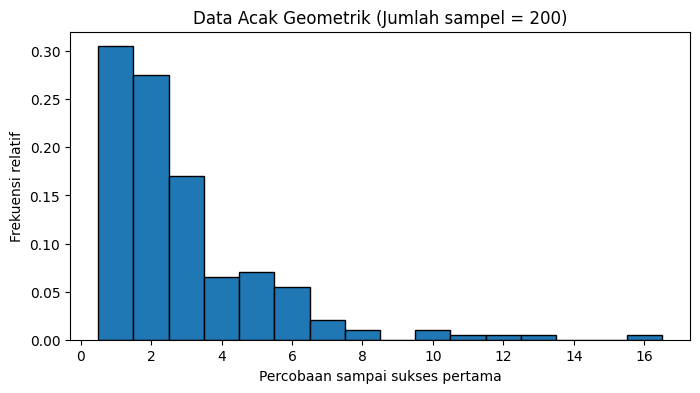

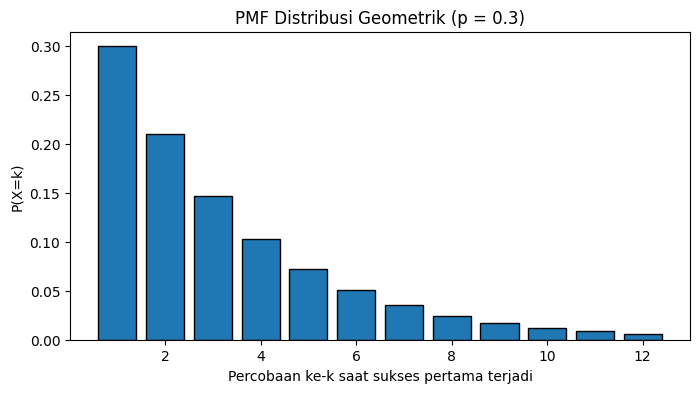

,k,P(X=k)
0,1,0.3000
1,2,0.2100
2,3,0.1470
3,4,0.1029
4,5,0.0720
5,6,0.0504
6,7,0.0353
7,8,0.0247
8,9,0.0173
9,10,0.0121


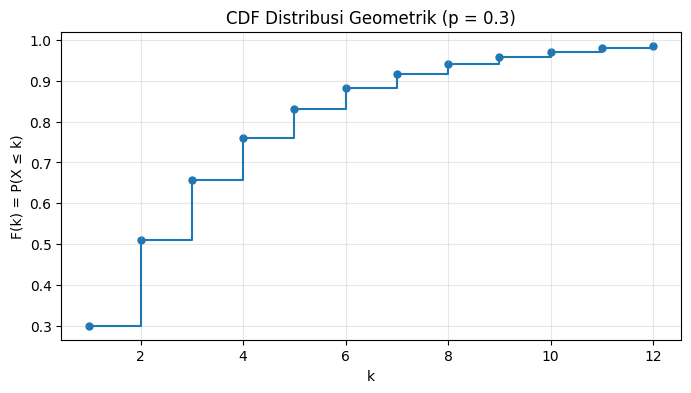

,Keterangan,Nilai
0,P(X=1),0.3000
1,P(X=3),0.1470
2,P(X≤4),0.7599
3,P(2≤X≤5),0.5319


,quantile,inverse CDF,CDF
0,0.10,1,0.3000
1,0.25,1,0.3000
2,0.50,2,0.5100
3,0.75,4,0.7599
4,0.90,7,0.9176


In [ ]:
# =========================================================
# Distribusi Geometrik
# =========================================================
p = 0.3

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = geom.rvs(p, size=200, random_state=rng)
display(pd.DataFrame({"Sampel Geometrik": sample}).head(10))

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=np.arange(sample.min() - 0.5, sample.max() + 1.5, 1),
         edgecolor="black", density=True)
plt.xlabel("Percobaan sampai sukses pertama")
plt.ylabel("Frekuensi relatif")
plt.title("Data Acak Geometrik (Jumlah sampel = 200)")
plt.show()

x = np.arange(1, 13)

# 2) Plot distribusi (PMF)
pmf = geom.pmf(x, p)
plt.figure(figsize=(8, 4))
plt.bar(x, pmf, edgecolor="black")
plt.xlabel("Percobaan ke-k saat sukses pertama terjadi")
plt.ylabel("P(X=k)")
plt.title("PMF Distribusi Geometrik (p = 0.3)")
plt.show()

display(pd.DataFrame({"k": x, "P(X=k)": pmf}))

# 3) Plot CDF
cdf = geom.cdf(x, p)
plt.figure(figsize=(8, 4))
plt.step(x, cdf, where="post")
plt.scatter(x, cdf, s=25)
plt.xlabel("k")
plt.ylabel("F(k) = P(X ≤ k)")
plt.title("CDF Distribusi Geometrik (p = 0.3)")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X=1)",
        "P(X=3)",
        "P(X≤4)",
        "P(2≤X≤5)"
    ],
    "Nilai": [
        geom.pmf(1, p),
        geom.pmf(3, p),
        geom.cdf(4, p),
        geom.cdf(5, p) - geom.cdf(1, p)
    ]
})
display(prob_table)

# 5) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
x_quant = geom.ppf(quantiles, p).astype(int)
cdf_at_quant = geom.cdf(x_quant, p)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))



### Interpretasi Geometrik

Distribusi geometrik biasanya **miring ke kanan**.  
Nilai kecil lebih mungkin muncul karena keberhasilan pertama cenderung terjadi **lebih awal** daripada **lebih lambat**, terutama jika peluang sukses cukup besar.

## Ringkasan distribusi diskrit

| Distribusi | Kapan digunakan? | Parameter | Mean | Varians |
|---|---|---:|---:|---:|
| Bernoulli | Satu percobaan, dua hasil | $p$ | $p$ | $p(1-p)$ |
| Binomial | Jumlah sukses dari $n$ percobaan | $n,p$ | $np$ | $np(1-p)$ |
| Poisson | Jumlah kejadian pada interval | $\lambda$ | $\lambda$ | $\lambda$ |
| Geometrik | Percobaan sampai sukses pertama | $p$ | $1/p$ | $(1-p)/p^2$ |

## Checkpoint 2

Tentukan distribusi yang paling tepat untuk masing-masing kasus berikut:

1. jumlah pelanggan yang datang ke ATM dalam 10 menit,  
2. apakah satu pasien merespons obat atau tidak,  
3. jumlah soal benar dari 20 soal,  
4. banyaknya lemparan koin sampai muncul gambar pertama.

Berikan alasan singkat.

In [ ]:
# ruang jawaban mahasiswa

# Bagian B — Distribusi Kontinu

Distribusi kontinu digunakan ketika variabel acak dapat mengambil **nilai pada suatu interval riil**.  
Kita akan membahas distribusi yang paling penting untuk pengantar statistika dan data science:

1. Uniform kontinu  
2. Normal  
3. Eksponensial  
4. Gamma  
5. Beta  
6. Chi-Square  
7. t-Student

## B1. Distribusi Uniform Kontinu

Distribusi uniform kontinu menyatakan bahwa semua nilai dalam interval $[a,b]$ memiliki **densitas yang sama**.


### Contoh:
- memilih bilangan acak dari suatu interval,
- simulasi awal tanpa preferensi nilai tertentu.

,Sampel Uniform
0,0.6824
1,0.0538
2,0.2204
3,0.1844
4,0.1759
5,0.8121
6,0.9233
7,0.2766
8,0.8198
9,0.8899


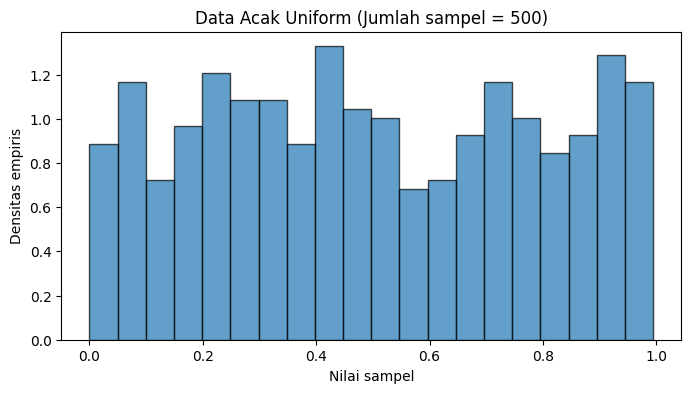

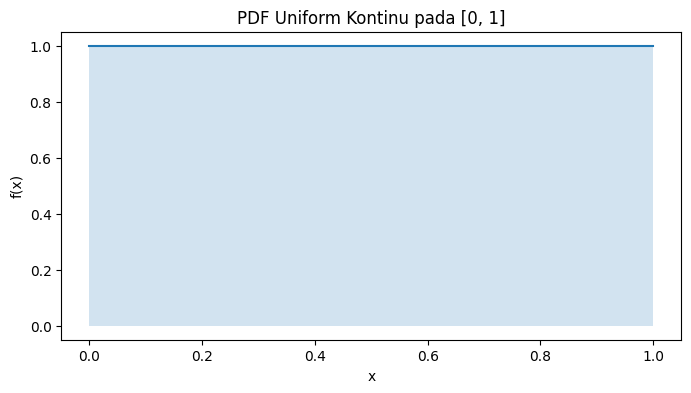

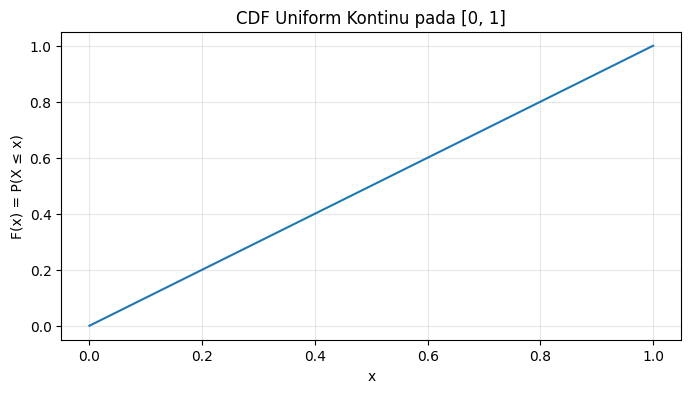

,Keterangan,Nilai
0,P(X≤0.30),0.30
1,P(X≤0.80),0.80
2,P(0.20≤X≤0.65),0.45


,quantile,inverse CDF,CDF
0,0.10,0.10,0.10
1,0.25,0.25,0.25
2,0.50,0.50,0.50
3,0.75,0.75,0.75
4,0.90,0.90,0.90


In [ ]:
# =========================================================
# Distribusi Uniform Kontinu
# =========================================================
a, b = 0, 1

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = uniform.rvs(loc=a, scale=b-a, size=500, random_state=rng)
display(pd.DataFrame({"Sampel Uniform": sample}).head(10))

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=20, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("Nilai sampel")
plt.ylabel("Densitas empiris")
plt.title("Data Acak Uniform (Jumlah sampel = 500)")
plt.show()

x = np.linspace(a, b, 400)

# 2) Plot distribusi (PDF)
pdf = uniform.pdf(x, loc=a, scale=b-a)
plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.fill_between(x, pdf, alpha=0.2)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PDF Uniform Kontinu pada [0, 1]")
plt.show()

# 3) Plot CDF
cdf = uniform.cdf(x, loc=a, scale=b-a)
plt.figure(figsize=(8, 4))
plt.plot(x, cdf)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF Uniform Kontinu pada [0, 1]")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
x1, x2 = 0.20, 0.65
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X≤0.30)",
        "P(X≤0.80)",
        "P(0.20≤X≤0.65)"
    ],
    "Nilai": [
        uniform.cdf(0.30, loc=a, scale=b-a),
        uniform.cdf(0.80, loc=a, scale=b-a),
        uniform.cdf(x2, loc=a, scale=b-a) - uniform.cdf(x1, loc=a, scale=b-a)
    ]
})
display(prob_table)

# 5) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
x_quant = uniform.ppf(quantiles, loc=a, scale=b-a)
cdf_at_quant = uniform.cdf(x_quant, loc=a, scale=b-a)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))



## B2. Distribusi Normal

Distribusi normal adalah distribusi kontinu yang sangat penting dalam statistika. Bentuknya simetris seperti lonceng.

Jika $X \sim N(\mu, \sigma^2)$, maka:
- $\mu$ menentukan pusat distribusi,
- $\sigma$ menentukan sebaran data.

### Mengapa penting?
- banyak fenomena alam mendekati distribusi normal,
- menjadi dasar banyak metode inferensi statistik,
- muncul dalam pembahasan **Central Limit Theorem**.

,Sampel Normal
0,-0.9891
1,-0.3678
2,1.2879
3,0.1940
4,0.9202
5,0.5771
6,-0.6365
7,0.5420
8,-0.3166
9,-0.3224


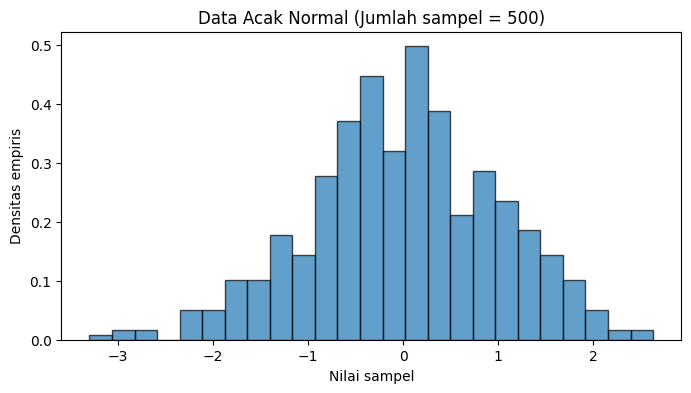

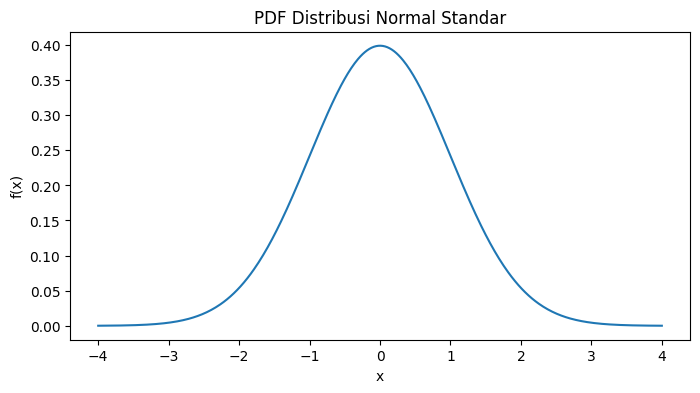

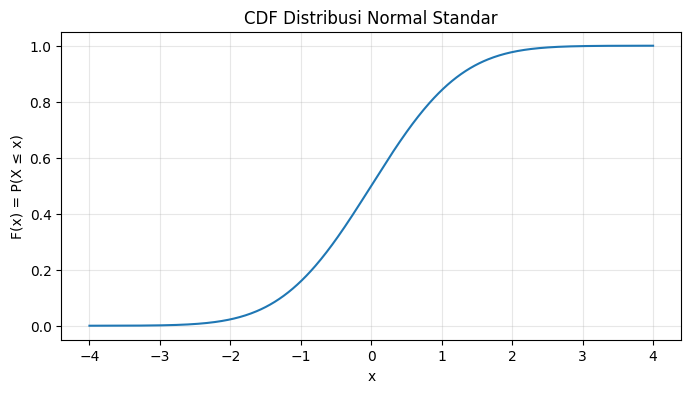

,Keterangan,Nilai
0,P(X≤0),0.5000
1,P(X≤1.96),0.9750
2,P(-1≤X≤1.5),0.7745


,quantile,inverse CDF,CDF
0,0.100,-1.2816,0.100
1,0.250,-0.6745,0.250
2,0.500,0.0000,0.500
3,0.750,0.6745,0.750
4,0.900,1.2816,0.900
5,0.975,1.9600,0.975


In [ ]:
# =========================================================
# Distribusi Normal
# =========================================================
mu, sigma = 0, 1

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = norm.rvs(loc=mu, scale=sigma, size=500, random_state=rng)
display(pd.DataFrame({"Sampel Normal": sample}).head(10))

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=25, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("Nilai sampel")
plt.ylabel("Densitas empiris")
plt.title("Data Acak Normal (Jumlah sampel = 500)")
plt.show()

x = np.linspace(-4, 4, 500)

# 2) Plot distribusi (PDF)
pdf = norm.pdf(x, loc=mu, scale=sigma)
plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PDF Distribusi Normal Standar")
plt.show()

# 3) Plot CDF
cdf = norm.cdf(x, loc=mu, scale=sigma)
plt.figure(figsize=(8, 4))
plt.plot(x, cdf)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF Distribusi Normal Standar")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
a_int, b_int = -1.0, 1.5
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X≤0)",
        "P(X≤1.96)",
        "P(-1≤X≤1.5)"
    ],
    "Nilai": [
        norm.cdf(0, loc=mu, scale=sigma),
        norm.cdf(1.96, loc=mu, scale=sigma),
        norm.cdf(b_int, loc=mu, scale=sigma) - norm.cdf(a_int, loc=mu, scale=sigma)
    ]
})
display(prob_table)

# 5) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90, 0.975])
x_quant = norm.ppf(quantiles, loc=mu, scale=sigma)
cdf_at_quant = norm.cdf(x_quant, loc=mu, scale=sigma)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))

### Interpretasi Normal

Distribusi normal:

- simetris terhadap rata-rata,
- mean = median = modus,
- sebagian besar data terkonsentrasi di sekitar pusat.

Untuk distribusi normal standar:
- sekitar 68% data berada pada $\mu \pm 1\sigma$,
- sekitar 95% data berada pada $\mu \pm 2\sigma$.

## B3. Distribusi Eksponensial

Distribusi eksponensial sering digunakan untuk memodelkan **waktu tunggu antar kejadian** pada proses Poisson.

### Contoh:
- waktu tunggu pelanggan berikutnya,
- waktu antar kerusakan mesin,
- waktu antar panggilan masuk.

,Sampel Eksponensial
0,0.3980
1,0.0780
2,0.1679
3,0.2053
4,0.0612
5,1.5677
6,2.8590
7,0.1031
8,0.3318
9,0.5509


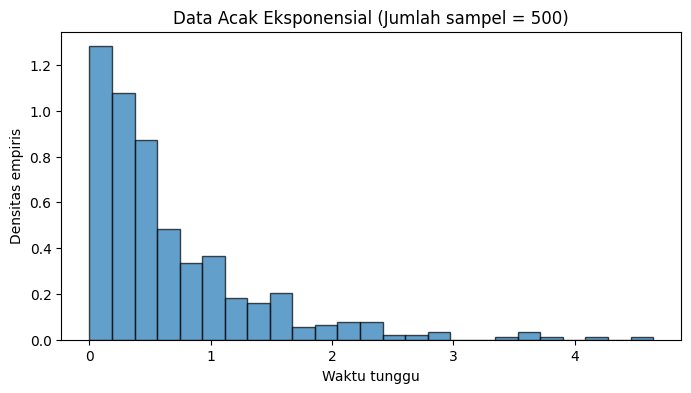

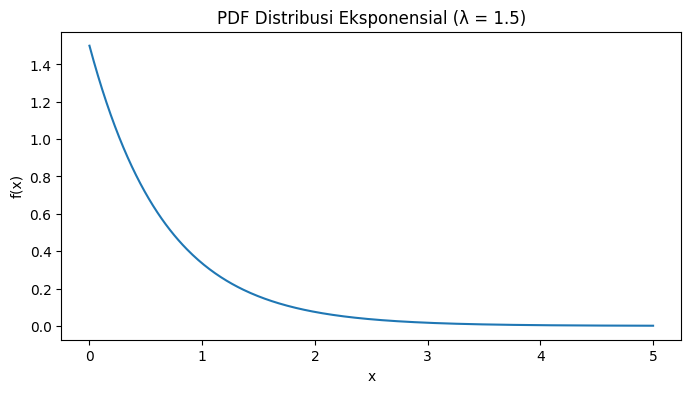

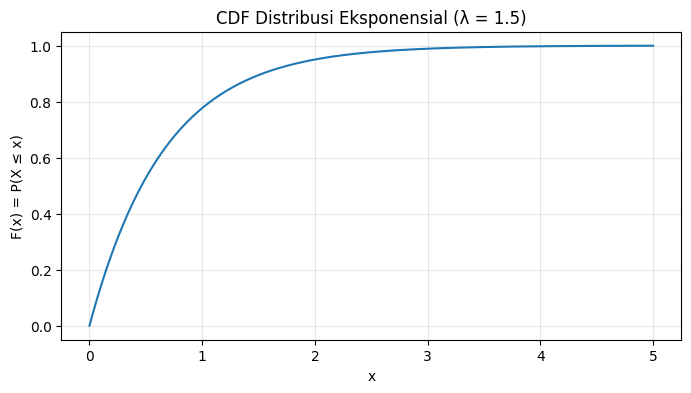

,Keterangan,Nilai
0,P(X≤1),0.7769
1,P(X≤2),0.9502
2,P(0.5≤X≤1.5),0.3670


,quantile,inverse CDF,CDF
0,0.10,0.0702,0.10
1,0.25,0.1918,0.25
2,0.50,0.4621,0.50
3,0.75,0.9242,0.75
4,0.90,1.5351,0.90


In [ ]:
# =========================================================
# Distribusi Eksponensial
# =========================================================
lam = 1.5

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = expon.rvs(scale=1/lam, size=500, random_state=rng)
display(pd.DataFrame({"Sampel Eksponensial": sample}).head(10))

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=25, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("Waktu tunggu")
plt.ylabel("Densitas empiris")
plt.title("Data Acak Eksponensial (Jumlah sampel = 500)")
plt.show()

x = np.linspace(0, 5, 400)

# 2) Plot distribusi (PDF)
pdf = expon.pdf(x, scale=1/lam)
plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PDF Distribusi Eksponensial (λ = 1.5)")
plt.show()

# 3) Plot CDF
cdf = expon.cdf(x, scale=1/lam)
plt.figure(figsize=(8, 4))
plt.plot(x, cdf)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF Distribusi Eksponensial (λ = 1.5)")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
a_int, b_int = 0.5, 1.5
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X≤1)",
        "P(X≤2)",
        "P(0.5≤X≤1.5)"
    ],
    "Nilai": [
        expon.cdf(1, scale=1/lam),
        expon.cdf(2, scale=1/lam),
        expon.cdf(b_int, scale=1/lam) - expon.cdf(a_int, scale=1/lam)
    ]
})
display(prob_table)

# 5) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
x_quant = expon.ppf(quantiles, scale=1/lam)
cdf_at_quant = expon.cdf(x_quant, scale=1/lam)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))

## B4. Distribusi Gamma

Distribusi gamma adalah generalisasi dari distribusi eksponensial dan sering digunakan untuk memodelkan waktu tunggu total sampai beberapa kejadian terjadi.

Jika $X \sim \text{Gamma}(\alpha, \theta)$, dengan:
- $\alpha$ = shape,
- $\theta$ = scale.

,Sampel Gamma
0,2.7112
1,10.7424
2,8.9387
3,3.5130
4,4.3647
5,5.6570
6,10.2513
7,9.3126
8,12.0648
9,4.3785


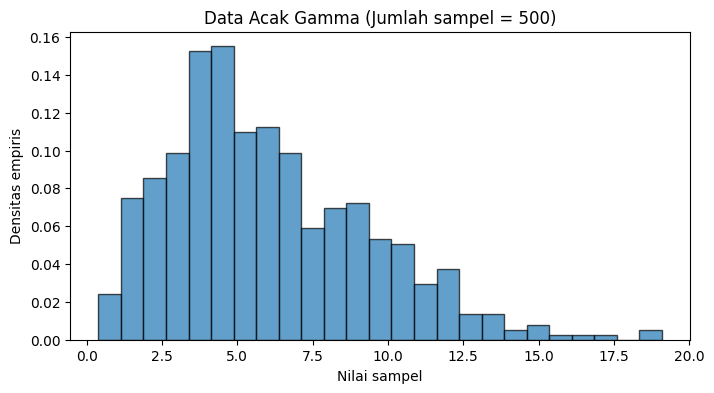

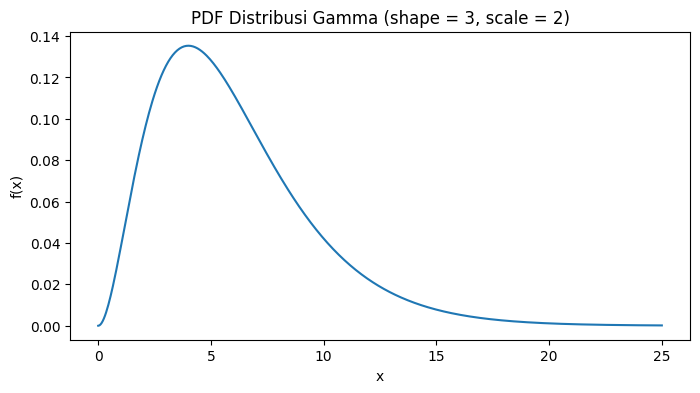

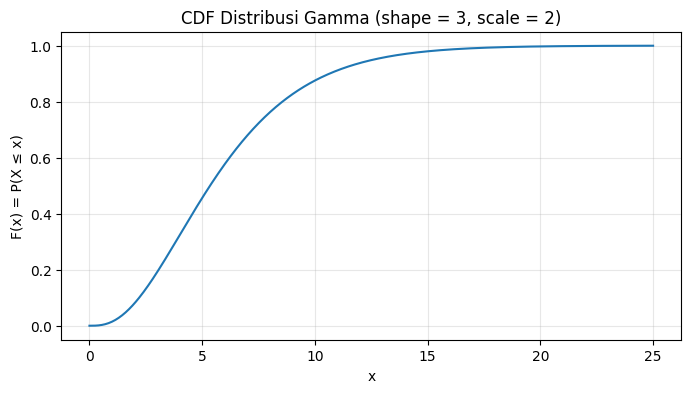

,Keterangan,Nilai
0,P(X≤5),0.4562
1,P(X≤10),0.8753
2,P(4≤X≤8),0.4386


,quantile,inverse CDF,CDF
0,0.10,2.2041,0.10
1,0.25,3.4546,0.25
2,0.50,5.3481,0.50
3,0.75,7.8408,0.75
4,0.90,10.6446,0.90


In [ ]:
# =========================================================
# Distribusi Gamma
# =========================================================
alpha, theta = 3, 2

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = gamma.rvs(a=alpha, scale=theta, size=500, random_state=rng)
display(pd.DataFrame({"Sampel Gamma": sample}).head(10))

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=25, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("Nilai sampel")
plt.ylabel("Densitas empiris")
plt.title("Data Acak Gamma (Jumlah sampel = 500)")
plt.show()

x = np.linspace(0, 25, 500)

# 2) Plot distribusi (PDF)
pdf = gamma.pdf(x, a=alpha, scale=theta)
plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PDF Distribusi Gamma (shape = 3, scale = 2)")
plt.show()

# 3) Plot CDF
cdf = gamma.cdf(x, a=alpha, scale=theta)
plt.figure(figsize=(8, 4))
plt.plot(x, cdf)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF Distribusi Gamma (shape = 3, scale = 2)")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
a_int, b_int = 4, 8
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X≤5)",
        "P(X≤10)",
        "P(4≤X≤8)"
    ],
    "Nilai": [
        gamma.cdf(5, a=alpha, scale=theta),
        gamma.cdf(10, a=alpha, scale=theta),
        gamma.cdf(b_int, a=alpha, scale=theta) - gamma.cdf(a_int, a=alpha, scale=theta)
    ]
})
display(prob_table)

# 5) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
x_quant = gamma.ppf(quantiles, a=alpha, scale=theta)
cdf_at_quant = gamma.cdf(x_quant, a=alpha, scale=theta)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))

## B5. Distribusi Beta

Distribusi beta didefinisikan pada interval **0 sampai 1**, sehingga sangat berguna untuk memodelkan:

- proporsi,
- probabilitas,
- tingkat keberhasilan relatif.

Jika $X \sim \text{Beta}(\alpha,\beta)$, maka:
\[
E(X)=\frac{\alpha}{\alpha+\beta}
\]

,Sampel Beta
0,0.0788
1,0.4800
2,0.2091
3,0.3418
4,0.5295
5,0.0148
6,0.2617
7,0.3618
8,0.4930
9,0.2982


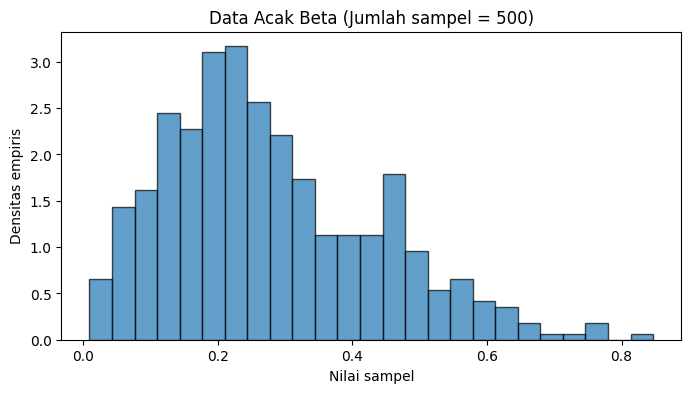

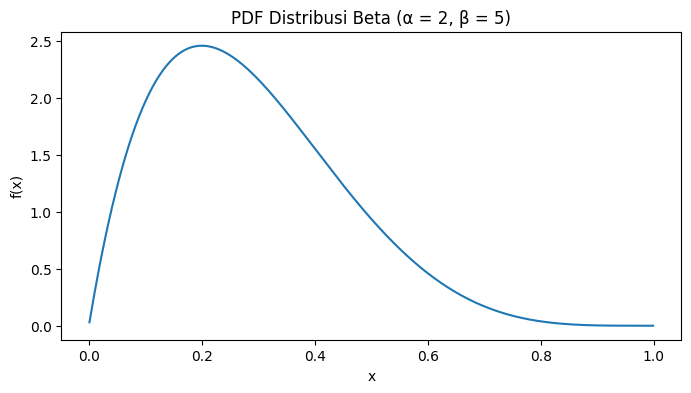

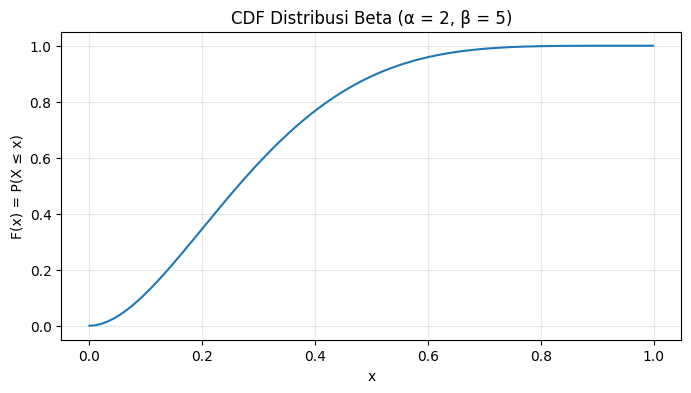

,Keterangan,Nilai
0,P(X≤0.30),0.5798
1,P(X≤0.60),0.9590
2,P(0.20≤X≤0.50),0.5460


,quantile,inverse CDF,CDF
0,0.10,0.0926,0.10
1,0.25,0.1612,0.25
2,0.50,0.2644,0.50
3,0.75,0.3895,0.75
4,0.90,0.5103,0.90


In [ ]:
# =========================================================
# Distribusi Beta
# =========================================================
alpha, beta_param = 2, 5

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = beta.rvs(a=alpha, b=beta_param, size=500, random_state=rng)
display(pd.DataFrame({"Sampel Beta": sample}).head(10))

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=25, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("Nilai sampel")
plt.ylabel("Densitas empiris")
plt.title("Data Acak Beta (Jumlah sampel = 500)")
plt.show()

x = np.linspace(0.001, 0.999, 500)

# 2) Plot distribusi (PDF)
pdf = beta.pdf(x, a=alpha, b=beta_param)
plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PDF Distribusi Beta (α = 2, β = 5)")
plt.show()

# 3) Plot CDF
cdf = beta.cdf(x, a=alpha, b=beta_param)
plt.figure(figsize=(8, 4))
plt.plot(x, cdf)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF Distribusi Beta (α = 2, β = 5)")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
a_int, b_int = 0.20, 0.50
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X≤0.30)",
        "P(X≤0.60)",
        "P(0.20≤X≤0.50)"
    ],
    "Nilai": [
        beta.cdf(0.30, a=alpha, b=beta_param),
        beta.cdf(0.60, a=alpha, b=beta_param),
        beta.cdf(b_int, a=alpha, b=beta_param) - beta.cdf(a_int, a=alpha, b=beta_param)
    ]
})
display(prob_table)

# 5) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
x_quant = beta.ppf(quantiles, a=alpha, b=beta_param)
cdf_at_quant = beta.cdf(x_quant, a=alpha, b=beta_param)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))

## B6. Distribusi Chi-Square

Distribusi chi-square banyak digunakan dalam inferensi statistik, terutama:

- uji chi-square,
- analisis varians tertentu,
- pembentukan distribusi sampling.

,Sampel Chi-Square
0,1.3761
1,7.8872
2,6.3186
3,1.9453
4,2.5809
5,3.5906
6,7.4562
7,6.6405
8,9.0601
9,2.5914


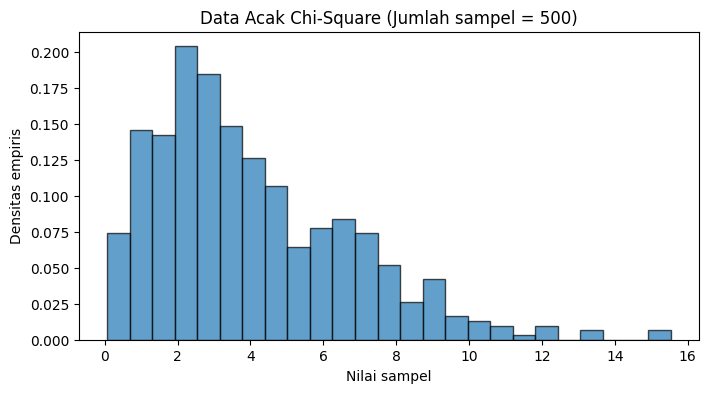

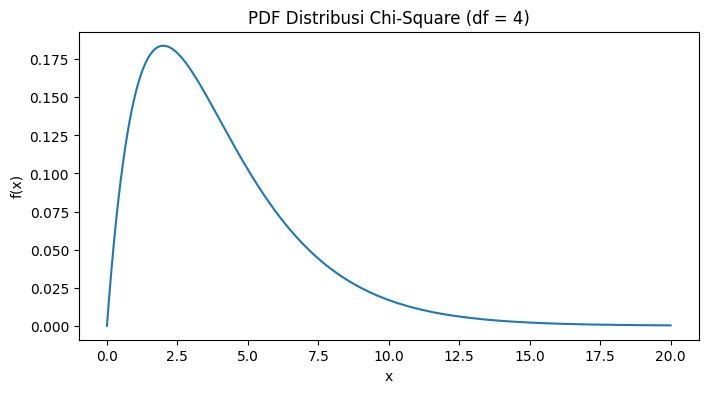

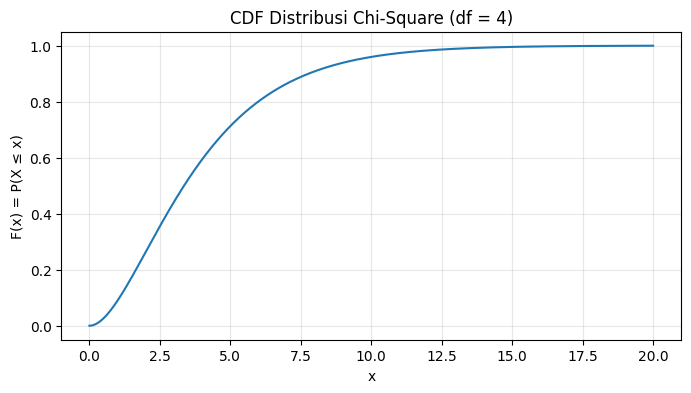

,Keterangan,Nilai
0,P(X≤3),0.4422
1,P(X≤5),0.7127
2,P(2≤X≤6),0.5366


,quantile,inverse CDF,CDF
0,0.10,1.0636,0.10
1,0.25,1.9226,0.25
2,0.50,3.3567,0.50
3,0.75,5.3853,0.75
4,0.90,7.7794,0.90
5,0.95,9.4877,0.95


In [ ]:
# =========================================================
# Distribusi Chi-Square
# =========================================================
df = 4

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = chi2.rvs(df=df, size=500, random_state=rng)
display(pd.DataFrame({"Sampel Chi-Square": sample}).head(10))

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=25, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("Nilai sampel")
plt.ylabel("Densitas empiris")
plt.title("Data Acak Chi-Square (Jumlah sampel = 500)")
plt.show()

x = np.linspace(0, 20, 500)

# 2) Plot distribusi (PDF)
pdf = chi2.pdf(x, df=df)
plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PDF Distribusi Chi-Square (df = 4)")
plt.show()

# 3) Plot CDF
cdf = chi2.cdf(x, df=df)
plt.figure(figsize=(8, 4))
plt.plot(x, cdf)
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF Distribusi Chi-Square (df = 4)")
plt.grid(alpha=0.3)
plt.show()

# 4) Perhitungan nilai peluang
a_int, b_int = 2, 6
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X≤3)",
        "P(X≤5)",
        "P(2≤X≤6)"
    ],
    "Nilai": [
        chi2.cdf(3, df=df),
        chi2.cdf(5, df=df),
        chi2.cdf(b_int, df=df) - chi2.cdf(a_int, df=df)
    ]
})
display(prob_table)

# 5) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
x_quant = chi2.ppf(quantiles, df=df)
cdf_at_quant = chi2.cdf(x_quant, df=df)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))

## B7. Distribusi t-Student

Distribusi t-Student mirip distribusi normal, tetapi memiliki **ekor lebih tebal**.  
Distribusi ini penting ketika:

- ukuran sampel kecil,
- simpangan baku populasi tidak diketahui.

Jika $X \sim t_\nu$, dengan $\nu$ derajat bebas, maka mean = 0 untuk $\nu > 1$.

,Sampel t-Student
0,-1.1176
1,0.1645
2,-0.5840
3,-0.3263
4,1.4539
5,0.1026
6,-0.2991
7,0.6222
8,0.8084
9,1.0178


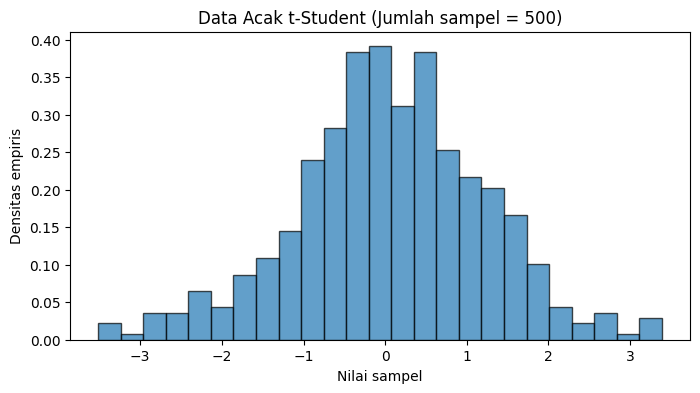

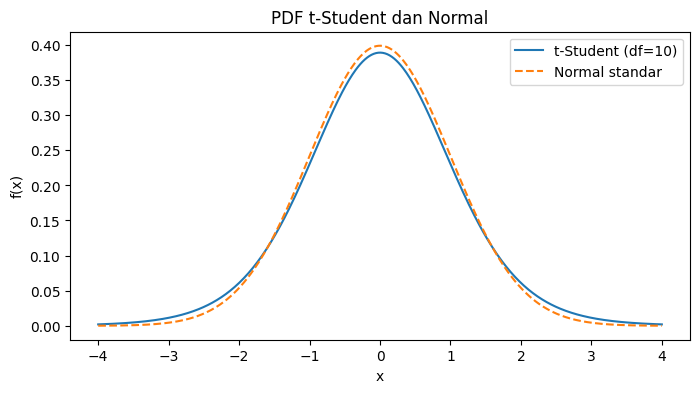

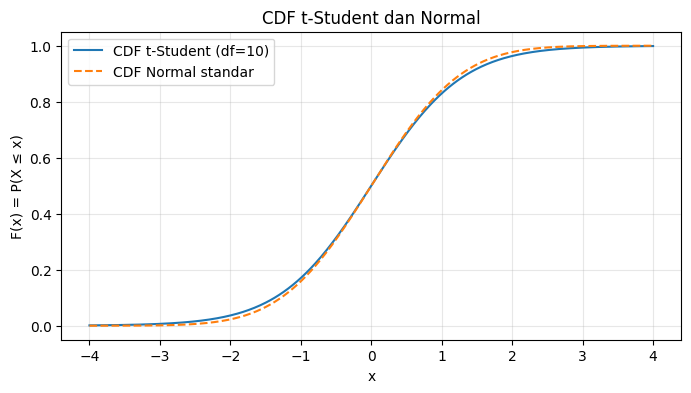

,Keterangan,Nilai
0,P(X≤0),0.5000
1,P(X≤1.812),0.9500
2,P(-1.5≤X≤1.5),0.8355


,quantile,inverse CDF,CDF
0,0.100,-1.3722e+00,0.100
1,0.250,-6.9981e-01,0.250
2,0.500,6.8057e-17,0.500
3,0.750,6.9981e-01,0.750
4,0.900,1.3722e+00,0.900
5,0.975,2.2281e+00,0.975


In [ ]:
# =========================================================
# Distribusi t-Student
# =========================================================
df = 10

# 1) Pembangkitan data acak
rng = np.random.default_rng(123)
sample = t.rvs(df=df, size=500, random_state=rng)
display(pd.DataFrame({"Sampel t-Student": sample}).head(10))

plt.figure(figsize=(8, 4))
plt.hist(sample, bins=25, density=True, edgecolor="black", alpha=0.7)
plt.xlabel("Nilai sampel")
plt.ylabel("Densitas empiris")
plt.title("Data Acak t-Student (Jumlah sampel = 500)")
plt.show()

x = np.linspace(-4, 4, 500)

# 1) Plot distribusi (PDF)
pdf_t = t.pdf(x, df=df)
pdf_norm = norm.pdf(x, 0, 1)
plt.figure(figsize=(8, 4))
plt.plot(x, pdf_t, label="t-Student (df=10)")
plt.plot(x, pdf_norm, linestyle="--", label="Normal standar")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PDF t-Student dan Normal")
plt.legend()
plt.show()

# 2) Plot CDF
cdf_t = t.cdf(x, df=df)
cdf_norm = norm.cdf(x, 0, 1)
plt.figure(figsize=(8, 4))
plt.plot(x, cdf_t, label="CDF t-Student (df=10)")
plt.plot(x, cdf_norm, linestyle="--", label="CDF Normal standar")
plt.xlabel("x")
plt.ylabel("F(x) = P(X ≤ x)")
plt.title("CDF t-Student dan Normal")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3) Perhitungan nilai peluang
a_int, b_int = -1.5, 1.5
prob_table = pd.DataFrame({
    "Keterangan": [
        "P(X≤0)",
        "P(X≤1.812)",
        "P(-1.5≤X≤1.5)"
    ],
    "Nilai": [
        t.cdf(0, df=df),
        t.cdf(1.812, df=df),
        t.cdf(b_int, df=df) - t.cdf(a_int, df=df)
    ]
})
display(prob_table)

# 4) Perhitungan kuantil dan invers
quantiles = np.array([0.10, 0.25, 0.50, 0.75, 0.90, 0.975])
x_quant = t.ppf(quantiles, df=df)
cdf_at_quant = t.cdf(x_quant, df=df)
display(pd.DataFrame({
    "quantile": quantiles,
    "inverse CDF": x_quant,
    "CDF": cdf_at_quant
}))

### Interpretasi t-Student

Dibanding normal standar, distribusi t-Student memiliki ekor lebih tebal.  
Artinya, distribusi ini memberi peluang lebih besar pada nilai yang relatif jauh dari pusat. Itulah sebabnya distribusi ini lebih cocok untuk inferensi pada sampel kecil.

## Tabel ringkas distribusi kontinu

| Distribusi | Kegunaan utama | Support |
|---|---|---|
| Uniform | semua nilai pada interval dianggap setara | $[a,b]$ |
| Normal | fenomena simetris, inferensi dasar | $(-\infty, \infty)$ |
| Eksponensial | waktu antar kejadian | $[0, \infty)$ |
| Gamma | waktu tunggu akumulatif | $[0, \infty)$ |
| Beta | proporsi / probabilitas | $(0,1)$ |
| Chi-Square | uji inferensial | $[0, \infty)$ |
| t-Student | inferensi sampel kecil | $(-\infty, \infty)$ |

## Checkpoint 3

Jawab singkat:

1. Mengapa peluang pada satu titik untuk peubah kontinu bernilai 0?  
2. Mengapa distribusi beta cocok untuk memodelkan proporsi?  
3. Kapan distribusi t-Student lebih relevan daripada distribusi normal?

In [ ]:
# ruang jawaban mahasiswa

# Bagian C — Nilai Harapan dan Varians

## C1. Nilai harapan

Nilai harapan adalah ukuran pusat teoritis dari suatu variabel acak.

Secara intuitif, nilai harapan dapat dipandang sebagai **rata-rata jangka panjang**.

In [ ]:
# contoh: nilai harapan lemparan dadu fair
x = np.arange(1, 7)
pmf = np.repeat(1/6, 6)

E_X = np.sum(x * pmf)
E_X

np.float64(3.5)

Pada dadu fair, perhatikan bahwa **3.5 bukan hasil yang mungkin muncul dalam satu lemparan**, tetapi merupakan **rata-rata teoritis jangka panjang**.

## C2. Varians

Varians mengukur besar penyebaran nilai terhadap nilai harapannya.

Untuk dadu fair:

In [ ]:
Var_X = np.sum((x - E_X)**2 * pmf)
SD_X = np.sqrt(Var_X)

print("Nilai harapan E(X) =", E_X)
print("Varians Var(X)     =", round(Var_X, 4))
print("Standar deviasi    =", round(SD_X, 4))

Nilai harapan E(X) = 3.5
Varians Var(X)     = 2.9167
Standar deviasi    = 1.7078


### Interpretasi

- **Nilai harapan** memberi tahu pusat distribusi.
- **Varians** memberi tahu seberapa menyebar nilai-nilai dari pusat tersebut.
- **Standar deviasi** adalah akar dari varians dan berada pada satuan yang sama dengan data.

Semakin besar varians, semakin besar ketidakpastian hasil.

## C3. Perbandingan mean teoritis dan mean empiris

Kita akan mensimulasikan banyak lemparan dadu, lalu membandingkan hasil empiris dengan nilai teoritis.

In [ ]:
sim_dadu = np.random.randint(1, 7, size=10000)

mean_empiris = sim_dadu.mean()
var_empiris = sim_dadu.var()

print("Mean teoritis   :", E_X)
print("Mean empiris    :", round(mean_empiris, 4))
print("Varians teoritis:", round(Var_X, 4))
print("Varians empiris :", round(var_empiris, 4))

Mean teoritis   : 3.5
Mean empiris    : 3.495
Varians teoritis: 2.9167
Varians empiris : 2.8566


Jika jumlah simulasi cukup besar, nilai empiris biasanya akan mendekati nilai teoritis.  
Inilah ide dasar yang nantinya terkait erat dengan **Law of Large Numbers**.

# Bagian D — Simulasi Distribusi

Simulasi sangat penting dalam data science karena:

- membantu memahami konsep abstrak secara visual,
- berguna ketika perhitungan analitik sulit,
- menjadi dasar metode Monte Carlo,
- membantu memeriksa perilaku model secara empiris.

## D1. Simulasi Bernoulli

Kasus: peluang satu pengguna mengklik iklan adalah 0.2.  
Kita simulasikan 1000 pengguna.

In [ ]:
klik = np.random.binomial(n=1, p=0.2, size=1000)
pd.Series(klik).value_counts().sort_index()

,count
0,822
1,178


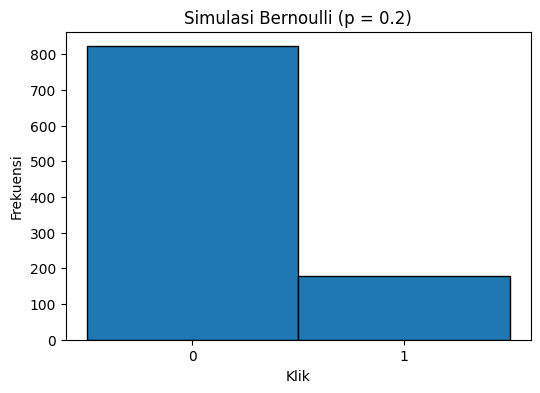

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(klik, bins=np.array([-0.5, 0.5, 1.5]), edgecolor="black")
plt.xticks([0, 1])
plt.xlabel("Klik")
plt.ylabel("Frekuensi")
plt.title("Simulasi Bernoulli (p = 0.2)")
plt.show()

## D2. Simulasi Binomial

Kasus: dari 20 pengguna, tiap pengguna memiliki peluang klik 0.2.  
Kita simulasikan 5000 kelompok pengguna.

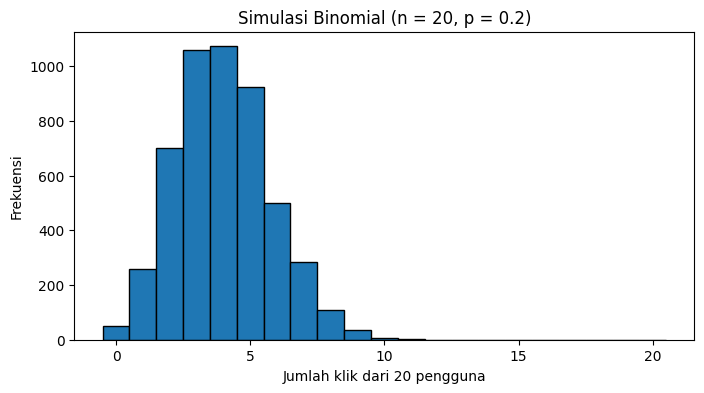

Mean empiris: 4.0044
Mean teoritis: 4.0


In [ ]:
binom_sim = np.random.binomial(n=20, p=0.2, size=5000)

plt.figure(figsize=(8, 4))
plt.hist(binom_sim, bins=np.arange(-0.5, 21.5, 1), edgecolor="black")
plt.xlabel("Jumlah klik dari 20 pengguna")
plt.ylabel("Frekuensi")
plt.title("Simulasi Binomial (n = 20, p = 0.2)")
plt.show()

print("Mean empiris:", round(binom_sim.mean(), 4))
print("Mean teoritis:", 20 * 0.2)

## D3. Simulasi Poisson

Kasus: rata-rata pelanggan datang 3 orang per menit.

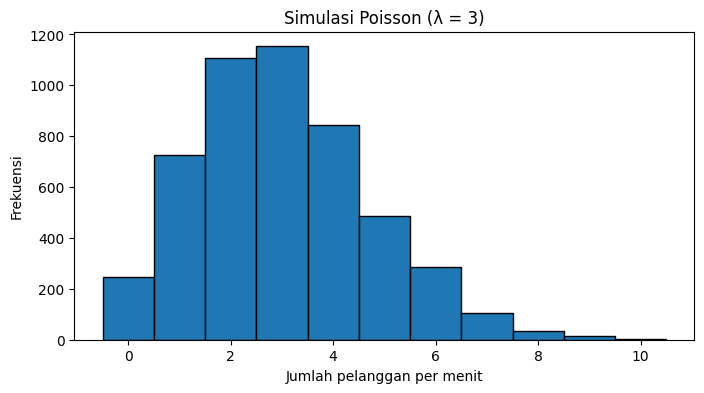

Mean empiris: 3.0148
Mean teoritis: 3


In [ ]:
pois_sim = np.random.poisson(lam=3, size=5000)

plt.figure(figsize=(8, 4))
plt.hist(pois_sim, bins=np.arange(-0.5, pois_sim.max() + 1.5, 1), edgecolor="black")
plt.xlabel("Jumlah pelanggan per menit")
plt.ylabel("Frekuensi")
plt.title("Simulasi Poisson (λ = 3)")
plt.show()

print("Mean empiris:", round(pois_sim.mean(), 4))
print("Mean teoritis:", 3)

## D4. Simulasi distribusi kontinu

Sekarang kita bandingkan beberapa distribusi kontinu melalui data hasil simulasi.

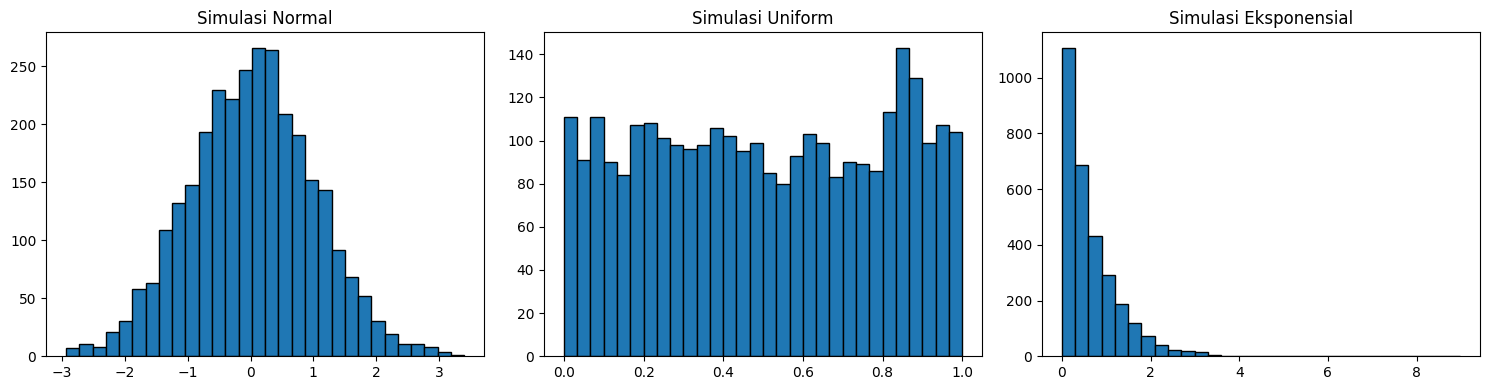

In [ ]:
normal_sim = np.random.normal(loc=0, scale=1, size=3000)
uniform_sim = np.random.uniform(low=0, high=1, size=3000)
exp_sim = np.random.exponential(scale=1/1.5, size=3000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(normal_sim, bins=30, edgecolor="black")
axes[0].set_title("Simulasi Normal")

axes[1].hist(uniform_sim, bins=30, edgecolor="black")
axes[1].set_title("Simulasi Uniform")

axes[2].hist(exp_sim, bins=30, edgecolor="black")
axes[2].set_title("Simulasi Eksponensial")

plt.tight_layout()
plt.show()

### Catatan interpretasi

- Histogram **normal** tampak simetris.
- Histogram **uniform** cenderung rata di seluruh interval.
- Histogram **eksponensial** cenderung miring ke kanan.

Ini menunjukkan bahwa **bentuk distribusi** memberi informasi penting tentang karakteristik data.

# Bagian E — Law of Large Numbers (LLN)

**LLN** menyatakan bahwa ketika jumlah pengamatan semakin besar, rata-rata sampel akan mendekati nilai harapan teoritis.

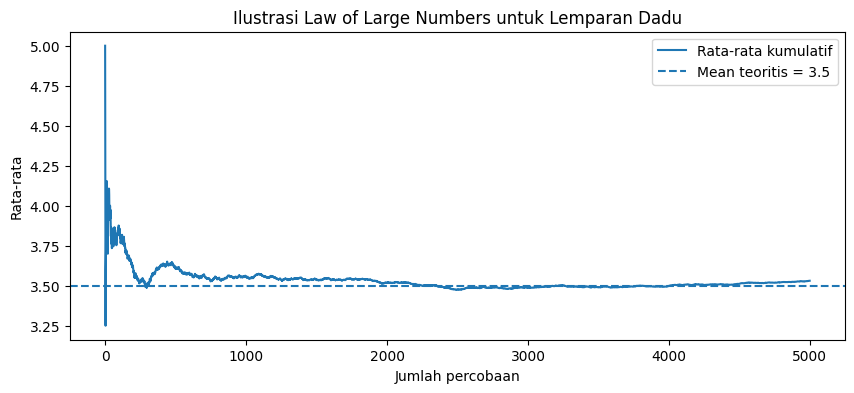

In [ ]:
lemparan = np.random.randint(1, 7, size=5000)
rata_kumulatif = np.cumsum(lemparan) / np.arange(1, len(lemparan) + 1)

plt.figure(figsize=(10, 4))
plt.plot(rata_kumulatif, label="Rata-rata kumulatif")
plt.axhline(E_X, linestyle="--", label="Mean teoritis = 3.5")
plt.xlabel("Jumlah percobaan")
plt.ylabel("Rata-rata")
plt.title("Ilustrasi Law of Large Numbers untuk Lemparan Dadu")
plt.legend()
plt.show()

### Interpretasi LLN

Pada awal percobaan, rata-rata kumulatif bisa berfluktuasi cukup besar.  
Namun, ketika jumlah percobaan bertambah, rata-rata kumulatif makin stabil dan mendekati **3.5**.

Ini menjelaskan mengapa pada data besar, statistik sampel sering menjadi estimasi yang baik bagi parameter populasi.

# Bagian F — Central Limit Theorem (CLT)

**CLT** menyatakan bahwa distribusi rata-rata sampel akan cenderung mendekati distribusi normal ketika ukuran sampel cukup besar, meskipun distribusi asal data tidak normal.

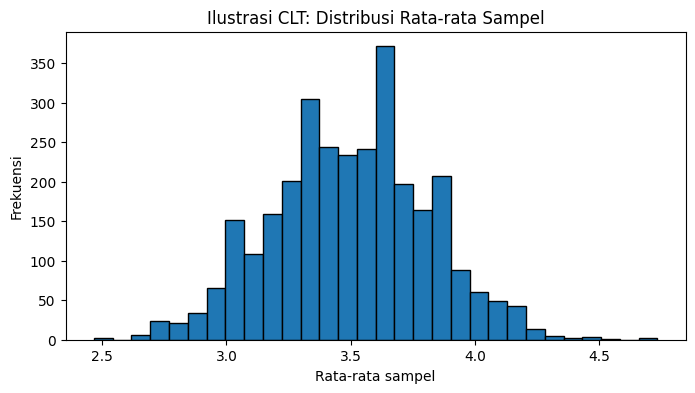

In [ ]:
n_sample = 30
n_replikasi = 3000

rata_sampel = []
for _ in range(n_replikasi):
    sampel = np.random.randint(1, 7, size=n_sample)  # populasi asal: dadu, tidak kontinu
    rata_sampel.append(sampel.mean())

rata_sampel = np.array(rata_sampel)

plt.figure(figsize=(8, 4))
plt.hist(rata_sampel, bins=30, edgecolor="black")
plt.xlabel("Rata-rata sampel")
plt.ylabel("Frekuensi")
plt.title("Ilustrasi CLT: Distribusi Rata-rata Sampel")
plt.show()

### Interpretasi CLT

Walaupun data asal berasal dari hasil lemparan dadu (diskrit), distribusi dari **rata-rata sampel** tampak mendekati bentuk lonceng.

Inilah alasan mengapa distribusi normal sangat penting dalam statistika inferensial.

## F2. Pengaruh ukuran sampel terhadap CLT

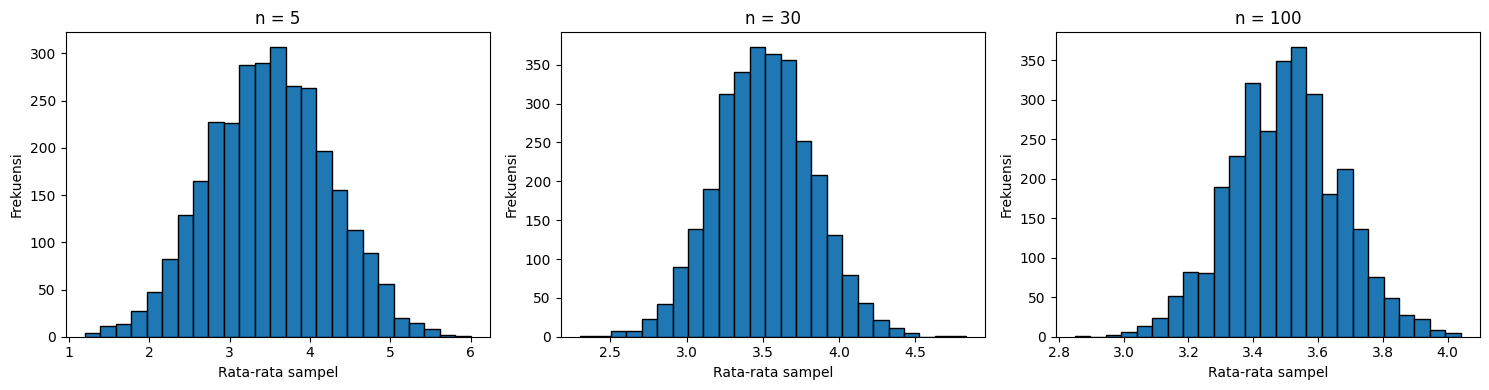

In [ ]:
def sample_means_from_dice(sample_size, n_rep=3000):
    means = []
    for _ in range(n_rep):
        sampel = np.random.randint(1, 7, size=sample_size)
        means.append(sampel.mean())
    return np.array(means)

means_5 = sample_means_from_dice(5)
means_30 = sample_means_from_dice(30)
means_100 = sample_means_from_dice(100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(means_5, bins=25, edgecolor="black")
axes[0].set_title("n = 5")

axes[1].hist(means_30, bins=25, edgecolor="black")
axes[1].set_title("n = 30")

axes[2].hist(means_100, bins=25, edgecolor="black")
axes[2].set_title("n = 100")

for ax in axes:
    ax.set_xlabel("Rata-rata sampel")
    ax.set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

### Interpretasi tambahan

Semakin besar ukuran sampel:

- distribusi rata-rata sampel semakin halus,
- distribusi makin mendekati normal,
- variasi rata-rata sampel semakin kecil.

Artinya, **estimasi berbasis rata-rata sampel menjadi lebih stabil**.

# Bagian G — Monte Carlo Simulation

Monte Carlo simulation menggunakan pengulangan acak dalam jumlah besar untuk mendekati nilai probabilitas atau besaran statistik.

## G1. Estimasi probabilitas dengan simulasi

Masalah: dua dadu fair dilempar.  
Taksir peluang bahwa jumlah kedua dadu **minimal 9**.

In [ ]:
n_sim = 100000
dadu1 = np.random.randint(1, 7, size=n_sim)
dadu2 = np.random.randint(1, 7, size=n_sim)
jumlah = dadu1 + dadu2

prob_empiris = np.mean(jumlah >= 9)
prob_empiris

np.float64(0.27799)

In [ ]:
# peluang teoritis
# jumlah >= 9 berarti: 9, 10, 11, 12
# banyak pasangan: 4 + 3 + 2 + 1 = 10 dari total 36
prob_teoritis = 10 / 36

print("Probabilitas empiris :", round(prob_empiris, 4))
print("Probabilitas teoritis:", round(prob_teoritis, 4))

Probabilitas empiris : 0.2784
Probabilitas teoritis: 0.2778


### Interpretasi Monte Carlo

Hasil simulasi sangat dekat dengan peluang teoritis.  
Ini menunjukkan bahwa simulasi dapat menjadi alat yang sangat berguna ketika:

- perhitungan teoritis sulit,
- model terlalu kompleks,
- kita ingin memahami perilaku probabilistik secara empiris.

# Bagian H — Latihan dan Refleksi

## Latihan 1

Sebuah perusahaan memiliki peluang **0.8** bahwa satu server dapat berjalan normal selama satu hari.

1. Nyatakan variabel acaknya.
2. Distribusi apa yang cocok?
3. Hitung mean dan varians teoritisnya.
4. Simulasikan 1000 hari operasi dengan Python.

In [ ]:
# ruang jawaban mahasiswa

## Latihan 2

Dalam 15 email yang masuk, peluang satu email adalah spam sebesar **0.25**.

1. Tentukan distribusi yang sesuai.
2. Hitung peluang terdapat tepat 4 email spam.
3. Hitung nilai harapan jumlah email spam.
4. Visualisasikan PMF-nya.

In [ ]:
# ruang jawaban mahasiswa

## Latihan 3

Jumlah pelanggan yang datang ke minimarket per 10 menit mengikuti distribusi Poisson dengan rata-rata **6**.

1. Hitung peluang tepat 8 pelanggan datang.
2. Hitung peluang paling banyak 5 pelanggan datang.
3. Simulasikan 5000 interval dan bandingkan mean empiris dengan mean teoritis.

In [ ]:
# ruang jawaban mahasiswa

## Latihan 4

Waktu tunggu pelanggan pada sebuah layanan diasumsikan mengikuti distribusi eksponensial dengan laju **2** per menit.

1. Tuliskan mean teoritisnya.
2. Simulasikan 3000 data waktu tunggu.
3. Buat histogramnya.
4. Jelaskan mengapa distribusi ini miring ke kanan.

In [ ]:
# ruang jawaban mahasiswa

## Latihan 5 — Eksplorasi CLT

Ulangi simulasi CLT untuk ukuran sampel:

- 5
- 20
- 50
- 100

Tuliskan kesimpulan Anda tentang pengaruh ukuran sampel terhadap bentuk distribusi rata-rata sampel.

In [ ]:
# ruang jawaban mahasiswa

# Bagian I — Ringkasan Konsep

Pada minggu ini, Anda telah mempelajari bahwa:

1. probabilitas membantu kita memodelkan ketidakpastian,
2. variabel acak dapat bersifat diskrit atau kontinu,
3. distribusi peluang menggambarkan bagaimana nilai acak tersebar,
4. nilai harapan dan varians adalah ringkasan utama distribusi,
5. simulasi sangat penting dalam statistika modern dan data science,
6. LLN menjelaskan mengapa rata-rata sampel mendekati mean populasi,
7. CLT menjelaskan mengapa rata-rata sampel sering mendekati normal.

## Tugas mandiri untuk mahasiswa

Gunakan Python untuk mengerjakan tugas berikut.

1. Buat satu contoh kasus **Bernoulli**, satu **Binomial**, satu **Poisson**, dan satu **Eksponensial** dari kehidupan sehari-hari atau dunia data science.
2. Untuk masing-masing kasus:
   - jelaskan variabel acaknya,
   - tentukan distribusinya,
   - tuliskan parameter utamanya,
   - buat satu simulasi sederhana,
   - berikan interpretasi hasil.
3. Tambahkan satu bagian khusus tentang **LLN** atau **CLT** berdasarkan salah satu distribusi yang Anda pilih.
4. Tulis kesimpulan akhir dalam **2–3 paragraf** dengan bahasa Anda sendiri.

> **Catatan penilaian:** ketepatan konsep, kebenaran kode, kualitas interpretasi, dan kerapian penyajian akan menjadi perhatian utama.

## Referensi konsep yang disarankan untuk dipelajari lanjut

- random variables,
- probability distributions,
- expectation and variance,
- sampling distribution,
- law of large numbers,
- central limit theorem,
- simulation and Monte Carlo methods.